The Random Forest Baseline
* Dataset: from sklearn.datasets import load_breast_cancer
* Objective: Understand the standard implementation and advantage of bagging.
* Task: Use scikit-learn to train a single DecisionTreeClassifier and a RandomForestClassifier on a standard dataset (like the Breast Cancer or Titanic dataset).
* Requirements:
    - Evaluate both models using Accuracy, Precision, Recall, and F1-score 
    - Plot the Feature Importances extracted from the Random Forest model.
    - Question to answer: How does the Random Forest mitigate the overfitting typically seen in deep, unpruned decision trees?


           DT Train  DT Test  RF Train  RF Test
Accuracy        1.0   0.9181       1.0   0.9357
Precision       1.0   0.9346       1.0   0.9444
Recall          1.0   0.9346       1.0   0.9533
F1-Score        1.0   0.9346       1.0   0.9488


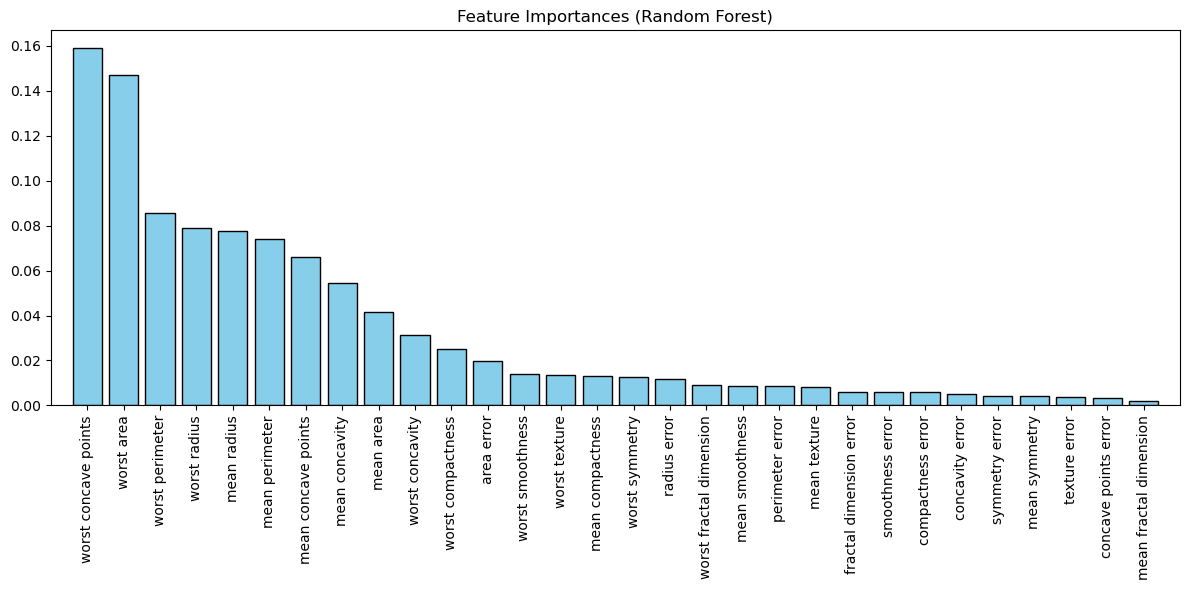

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

metrics_index = ["Accuracy", "Precision", "Recall", "F1-Score"]
df_results = pd.DataFrame(index=metrics_index)

splits = [
    ("DT Train", y_train, dt_model.predict(X_train)),
    ("DT Test",  y_test,  dt_model.predict(X_test)),
    ("RF Train", y_train, rf_model.predict(X_train)),
    ("RF Test",  y_test,  rf_model.predict(X_test))
]

for col_name, y_true, y_pred in splits:
    df_results[col_name] = [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]
    
print(df_results.round(4))

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color="skyblue", edgecolor="black")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

Building a Bagging Meta-Estimator
* Dataset: from sklearn.datasets import load_breast_cancer
* Objective: Understand how bootstrap sampling works under the hood.
* Task: Instead of using RandomForestClassifier, use scikit-learn's BaggingClassifier wrapper.
* Requirements:
    - Use a high-variance model (like a deep Decision Tree) and a low-variance model (like Logistic Regression) as the base estimators for two separate Bagging Classifiers.
    - Experiment with the max_samples and max_features hyperparameters.
    - Analyze how bagging affects the performance of the high-variance vs. low-variance base estimators differently.


In [8]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

high_var_tree = DecisionTreeClassifier(max_depth=None, random_state=42)
low_var_lr = LogisticRegression(max_iter=10000, random_state=42)

def run_bagging(base, name, max_samples=1.0, max_features=1.0):
    bag = BaggingClassifier(
        estimator=base, n_estimators=50, 
        max_samples=max_samples, max_features=max_features, 
        bootstrap=True, random_state=42
    ).fit(X_train, y_train)
    
    print(f"{name} (samples={max_samples}, features={max_features}) -> Test Accuracy: {bag.score(X_test, y_test):.4f}")

print("--- Standard Bagging ---")
run_bagging(high_var_tree, "Bagged Tree")
run_bagging(low_var_lr, "Bagged LR")

print("\n--- Tuning max_samples (Row Subsampling) ---")
run_bagging(high_var_tree, "Bagged Tree", max_samples=0.5)
run_bagging(low_var_lr, "Bagged LR", max_samples=0.5)

print("\n--- Tuning max_features (Column Subsampling) ---")
run_bagging(high_var_tree, "Bagged Tree", max_features=0.6)
run_bagging(low_var_lr, "Bagged LR", max_features=0.6)

--- Standard Bagging ---
Bagged Tree (samples=1.0, features=1.0) -> Test Accuracy: 0.9591
Bagged LR (samples=1.0, features=1.0) -> Test Accuracy: 0.9766

--- Tuning max_samples (Row Subsampling) ---
Bagged Tree (samples=0.5, features=1.0) -> Test Accuracy: 0.9649
Bagged LR (samples=0.5, features=1.0) -> Test Accuracy: 0.9766

--- Tuning max_features (Column Subsampling) ---
Bagged Tree (samples=1.0, features=0.6) -> Test Accuracy: 0.9591
Bagged LR (samples=1.0, features=0.6) -> Test Accuracy: 0.9766
